<a href="https://colab.research.google.com/github/DBH0112/epl-covid-home-advantage/blob/main/Covid_Home_Advantage_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Column Reference

**Match Info**
- `Date` — Match date
- `HomeTeam` / `AwayTeam` — Home team / Away team
- `Referee` — Match referee

**Result**
- `FTHG` / `FTAG` — Full Time Home/Away Goals
- `FTR` — Full Time Result (H = Home win, D = Draw, A = Away win)
- `HTHG` / `HTAG` — Half Time Home/Away Goals
- `HTR` — Half Time Result (H/D/A)

**Shooting**
- `HS` / `AS` — Home/Away Shots
- `HST` / `AST` — Home/Away Shots on Target

**Fouls & Cards**
- `HF` / `AF` — Home/Away Fouls
- `HY` / `AY` — Home/Away Yellow Cards
- `HR` / `AR` — Home/Away Red Cards

**Set Pieces**
- `HC` / `AC` — Home/Away Corners

**Added Column**
- `Season` — Season identifier, manually added during data loading (not present in the original source files)

*Source: [football-data.co.uk](http://www.football-data.co.uk/), mirrored via [datahub.io](https://datahub.io/football/english-premier-league)*

In [ ]:
import pandas as pd

seasons = ["1415", "1516", "1617", "1718", "1819", "2021", "2122", "2223", "2324", "2425", "2526"]

dfs = []
for season in seasons:
    url = "https://datahub.io/football/english-premier-league/_r/-/season-{}.csv".format(season)
    df = pd.read_csv(url)
    df["Season"] = season # tag rows with season so they can be identified after concat
    dfs.append(df)

In [ ]:
all_seasons = pd.concat(dfs, ignore_index=True) # combine all 11 seasons; reset index so rows are numbered 0 to end

# Sanity check: verify row/column counts and preview the data
all_seasons.shape
all_seasons.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2014-08-16,Arsenal,Crystal Palace,2,1,H,1,1,D,J Moss,...,2,13,19,9,3,2,2,0,1,1415
1,2014-08-16,Leicester,Everton,2,2,D,1,2,A,M Jones,...,3,16,10,3,6,1,1,0,0,1415
2,2014-08-16,Man United,Swansea,1,2,A,0,1,A,M Dean,...,4,14,20,4,0,2,4,0,0,1415
3,2014-08-16,QPR,Hull,0,1,A,0,0,D,C Pawson,...,4,10,10,8,9,1,2,0,0,1415
4,2014-08-16,Stoke,Aston Villa,0,1,A,0,0,D,A Taylor,...,2,14,9,2,8,0,3,0,0,1415


In [ ]:
# Check if there is any missing data from the 'all_seasons' df
missing = all_seasons.isnull().sum()
missing[missing > 0]

,0


In [ ]:
all_seasons["Home Win"] = all_seasons["FTR"] == "H" # True if the home team won, False otherwise
home_win_rate = all_seasons.groupby("Season")["Home Win"].mean() # mean of True/False = win rate per season
print(home_win_rate)


Season
1415    0.452632
1516    0.413158
1617    0.492105
1718    0.455263
1819    0.476316
2021    0.378947
2122    0.428947
2223    0.484211
2324    0.460526
2425    0.407895
2526    0.426316
Name: Home Win, dtype: float64


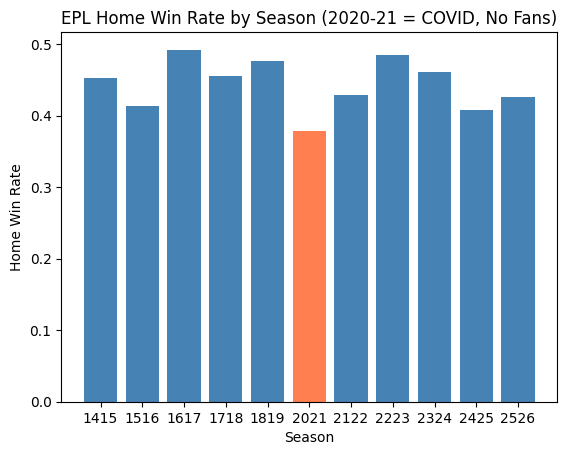

In [ ]:
import matplotlib.pyplot as plt

colors = []
for season in home_win_rate.index:
    if season == "2021":
        colors.append("coral")
    else:
        colors.append("steelblue")

plt.bar(home_win_rate.index, home_win_rate.values, color=colors)
plt.xlabel("Season")
plt.ylabel("Home Win Rate")
plt.title("EPL Home Win Rate by Season (2020-21 = COVID, No Fans)")
plt.show()

In [ ]:
covid_games = all_seasons[all_seasons["Season"] == "2021"]
normal_games = all_seasons[all_seasons["Season"] != "2021"]

covid_home_wins = covid_games["Home Win"].sum()
covid_total = len(covid_games)

normal_home_wins = normal_games["Home Win"].sum()
normal_total = len(normal_games)

print(covid_home_wins, covid_total)
print(normal_home_wins, normal_total)

144 380
1709 3800


## Statistical Significance Test

To check whether the drop in home win rate during the COVID season was random variation, I ran a **two-proportion z-test** comparing the 2020-21 (no-fan) season against the other 10 normal seasons.

**Hypotheses**
- H0 (null): Home win rate is the same in the COVID season and normal seasons
- H1 (alternative): Home win rate is lower in the COVID season

**Result**: p = 0.0040, well below the 0.05 threshold. The drop is statistically significant, supporting the hypothesis that the absence of fans reduced home advantage.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

count = [covid_home_wins, normal_home_wins]
nobs = [covid_total, normal_total]

z_stat, p_value = proportions_ztest(count, nobs, alternative="smaller")

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

z-statistic: -2.649
p-value: 0.0040


## Conclusion

Home win rate dropped to 37.9% during the 2020-21 no-fan season, compared to a 45.0% average across the other 10 seasons (2014-15 to 2024-25, excluding 2020-21). It's lower than every individual normal season, including the weakest one (40.8% in 2024-25).

A two-proportion z-test put this gap at p = 0.0040, well under the 0.05 cutoff.

The league, teams, and season length stayed constant, and crowd presence was the main variable that changed. This comes close to a natural experiment, and it's reasonably strong evidence that crowds affect home advantage.

## Limitations

The 2020-21 season also had a compressed fixture schedule and general pandemic disruption, so some of the drop could be from fatigue rather than the crowd itself.

The 2019-20 season was excluded since it switched to no-fan matches partway through, which would have confounded the comparison.

2014-15 was chosen as the starting point to keep playing style reasonably consistent across seasons.

Home advantage depends on many other factors (travel, rivalries, weather, referee decisions) that this analysis doesn't control for individually.